In [1]:
# Day16_Trajectory_Visualization_YAxis_Inversion_and_Frame_to_Frame_Speed_Calculation

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.7 MB/s eta 0:00:00


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from ultralytics import YOLO
import pandas as pd
model = YOLO('yolov8n.pt')
NaN = np.nan

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
cap = cv2.VideoCapture("/content/football_clip.mp4")
cap.get(cv2.CAP_PROP_FPS)# — frames per second
cap.get(cv2.CAP_PROP_FRAME_COUNT) #— total number of frames

print(cap.get(cv2.CAP_PROP_FPS))
print(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_count = 0
saved_frame = []
ret = True
while ret:
  ret,frame = cap.read()
  if frame_count % 10 ==0:
    saved_frame.append(frame)
  frame_count+=1
print(len(saved_frame))

print(saved_frame[-1] is None)


25.0
379.0
38
False


In [5]:
def detect_ball_yolo(image_path,conf_threshold):
  print()
  results = model.predict(image_path, conf=conf_threshold, verbose=False)
  for box in results[0].boxes:
    if int(box.cls[0]) == 32:
      print("===================")
      print("YOLO detection used")
      print("===================")
      annotated = results[0].plot()
      plt.imshow(annotated)
      plt.axis('off')
      plt.show()
      x1, y1, x2, y2 = box.xyxy[0]
      cx = float((x1 + x2) / 2)
      cy = float((y1 + y2) / 2)
      width = float(x2 - x1)
      height = float(y2 - y1)
      print(f"Ball box size: width={width}, height={height}")
      return float(box.conf[0]), (cx, cy)
  return NaN, NaN




def detect_ball(image_path, lower, upper):

 #load image
  if isinstance(image_path, str):
    img = cv2.imread(image_path)
  else:
    img = image_path
  # convert to HSV
  hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

  # create mask
  mask = cv2.inRange(hsv,lower,upper)

  # find contours
  contour_exter,hierarchy = cv2.findContours(
      mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
  )
  # filter by area + circularity
  best_ratio =0
  best_contour = None
  best_radius = None
  best_center = None
  for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
      center, radius = cv2.minEnclosingCircle(contour)
      circle_area = np.pi * radius**2
      ratio = area / circle_area
      if ratio > 0.7 and ratio > best_ratio and radius < 150 and radius > 15 :
        best_ratio = ratio
        best_contour = contour
        best_radius = radius
        best_center = center

  if best_center is None:
    print("HSV also failed to detect the ball")
    return NaN,NaN
  # print(best_ratio,best_radius)


  # draw result
  img_copy= img.copy()
  center_int = (int(best_center[0]),int(best_center[1]))
  radius_int = int(best_radius)
  cv2.circle(img_copy,center_int,radius_int,(0,255,0),4)

  # return or display the image
  plt.imshow(cv2.cvtColor(img_copy,cv2.COLOR_BGR2RGB))
  plt.show()
  return best_center, best_radius



def detect_ball_hybrid(image_path, conf_threshold=0.4):

  conf, center = detect_ball_yolo(image_path,conf_threshold)
  if conf is not None and conf>=conf_threshold:
    print("\n")
    print(f"Confidence of finding ball is : {conf}")
    return center

  else:
    print("\n")
    print("============================================================")
    print("YOLO failed or low confidence — falling back to HSV detection")
    print("============================================================")
    lower_int = np.array([0, 0, 180])
    upper_int = np.array([179, 60, 255])
    result = detect_ball(image_path, lower_int, upper_int)
    if np.isnan(result[0]):
      print("Both YOLO and HSV failed to detect the ball")
      return NaN,NaN
    center_2, radius_2 = result
    print("\n")
    print(f"The best center and radius are : {center_2}, {radius_2}")
    return center_2











YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect t

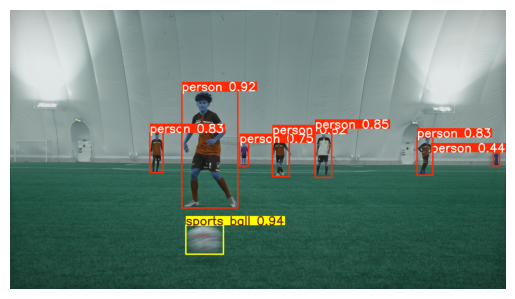

Ball box size: width=290.9783935546875, height=225.650390625


Confidence of finding ball is : 0.9403582811355591

YOLO detection used


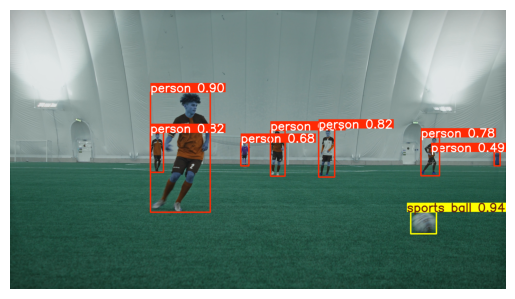

Ball box size: width=198.73388671875, height=170.228759765625


Confidence of finding ball is : 0.9445874094963074



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball

YOLO detection used


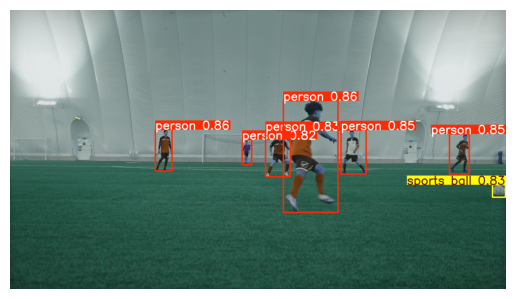

Ball box size: width=100.03125, height=96.671630859375


Confidence of finding ball is : 0.832416296005249

YOLO detection used


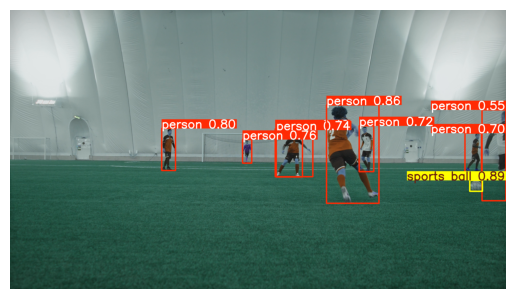

Ball box size: width=98.4814453125, height=84.1556396484375


Confidence of finding ball is : 0.889009952545166

YOLO detection used


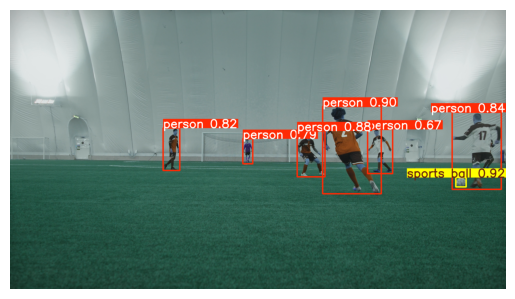

Ball box size: width=79.801025390625, height=72.4315185546875


Confidence of finding ball is : 0.9243007302284241



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball

YOLO detection used


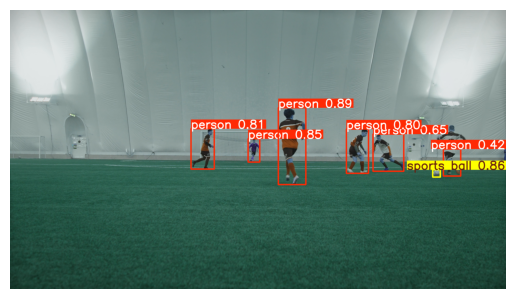

Ball box size: width=58.165283203125, height=56.481201171875


Confidence of finding ball is : 0.8622209429740906



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low confidence — falling back to HSV detection
HSV also failed to detect the ball
Both YOLO and HSV failed to detect the ball



YOLO failed or low 

In [6]:
centroid_history =[]
for frame in saved_frame :
  result = detect_ball_hybrid(frame)
  centroid_history.append(result)

In [7]:
print(centroid_history)
df = pd.DataFrame(centroid_history, columns=['x', 'y'])
print(df)

[(nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (1506.662109375, 1777.89599609375), (3202.347900390625, 1647.324462890625), (nan, nan), (nan, nan), (3785.332763671875, 1400.7430419921875), (3608.7080078125, 1360.932373046875), (3491.212890625, 1333.033203125), (nan, nan), (nan, nan), (3302.00830078125, 1265.2178955078125), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan), (nan, nan)]
              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9           NaN          NaN
10          NaN          NaN
11  3785.332764  1400.743042
12  3608.

In [8]:
df_interp = df.interpolate()
df_interp['x'].rolling(window=3).mean()
print(df_interp)

              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9   3396.676188  1565.130656
10  3591.004476  1482.936849
11  3785.332764  1400.743042
12  3608.708008  1360.932373
13  3491.212891  1333.033203
14  3428.144694  1310.428101
15  3365.076497  1287.822998
16  3302.008301  1265.217896
17  3302.008301  1265.217896
18  3302.008301  1265.217896
19  3302.008301  1265.217896
20  3302.008301  1265.217896
21  3302.008301  1265.217896
22  3302.008301  1265.217896
23  3302.008301  1265.217896
24  3302.008301  1265.217896
25  3302.008301  1265.217896
26  3302.008301  1265.217896
27  3302.008301  1265.217896
28  3302.008301  1265.217896
29  3302.008301  1265.217896
30  3302.008301  1265.217896
31  3302.008301  1265.217896
32  3302.008301  1265.217896
33  3302.00830

In [9]:
df_interp = df.interpolate(limit_area='inside')

print(df_interp)

              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7   1506.662109  1777.895996
8   3202.347900  1647.324463
9   3396.676188  1565.130656
10  3591.004476  1482.936849
11  3785.332764  1400.743042
12  3608.708008  1360.932373
13  3491.212891  1333.033203
14  3428.144694  1310.428101
15  3365.076497  1287.822998
16  3302.008301  1265.217896
17          NaN          NaN
18          NaN          NaN
19          NaN          NaN
20          NaN          NaN
21          NaN          NaN
22          NaN          NaN
23          NaN          NaN
24          NaN          NaN
25          NaN          NaN
26          NaN          NaN
27          NaN          NaN
28          NaN          NaN
29          NaN          NaN
30          NaN          NaN
31          NaN          NaN
32          NaN          NaN
33          Na

In [10]:
df_interp['x'].rolling(window=3).mean()


,x
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,2701.895399


In [11]:
df_interp['y'].rolling(window=3).mean()

,y
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,1663.450372


In [12]:
df_smooth = df_interp.rolling(window=3).mean()
print(df_smooth)

              x            y
0           NaN          NaN
1           NaN          NaN
2           NaN          NaN
3           NaN          NaN
4           NaN          NaN
5           NaN          NaN
6           NaN          NaN
7           NaN          NaN
8           NaN          NaN
9   2701.895399  1663.450372
10  3396.676188  1565.130656
11  3591.004476  1482.936849
12  3661.681749  1414.870755
13  3628.417887  1364.902873
14  3509.355197  1334.797892
15  3428.144694  1310.428101
16  3365.076497  1287.822998
17          NaN          NaN
18          NaN          NaN
19          NaN          NaN
20          NaN          NaN
21          NaN          NaN
22          NaN          NaN
23          NaN          NaN
24          NaN          NaN
25          NaN          NaN
26          NaN          NaN
27          NaN          NaN
28          NaN          NaN
29          NaN          NaN
30          NaN          NaN
31          NaN          NaN
32          NaN          NaN
33          Na

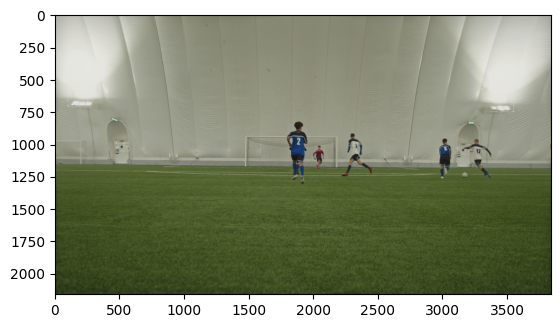

In [13]:
plt.imshow(cv2.cvtColor(saved_frame[17], cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(saved_frame[18], cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(saved_frame[19], cv2.COLOR_BGR2RGB))
plt.show()

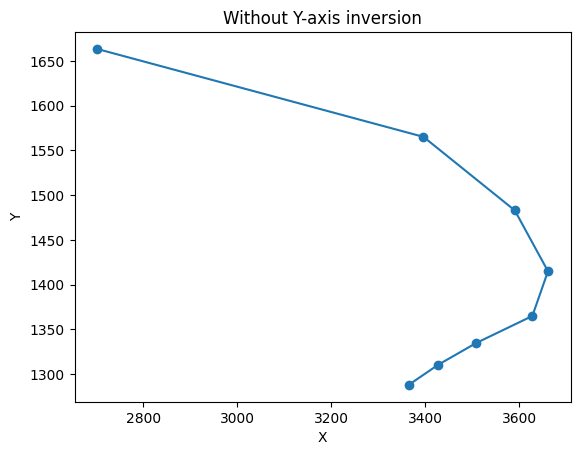

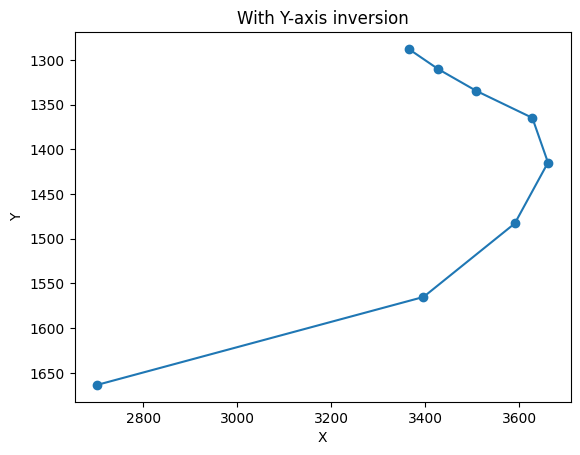

In [15]:
# without inversion
plt.plot(df_smooth['x'], df_smooth['y'], marker='o')
plt.title("Without Y-axis inversion")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# with inversion
plt.plot(df_smooth['x'], df_smooth['y'], marker='o')
plt.gca().invert_yaxis()
plt.title("With Y-axis inversion")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [21]:
fps = cap.get(cv2.CAP_PROP_FPS)
time_per_frame = 1/ fps
print(time_per_frame)
print(fps)

0.04
25.0


In [19]:
dx = df_smooth["x"].diff()
dy = df_smooth["y"].diff()

print(dx)

print(dy)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
10    694.780789
11    194.328288
12     70.677273
13    -33.263862
14   -119.062690
15    -81.210503
16    -63.068197
17           NaN
18           NaN
19           NaN
20           NaN
21           NaN
22           NaN
23           NaN
24           NaN
25           NaN
26           NaN
27           NaN
28           NaN
29           NaN
30           NaN
31           NaN
32           NaN
33           NaN
34           NaN
35           NaN
36           NaN
37           NaN
Name: x, dtype: float64
0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10   -98.319716
11   -82.193807
12   -68.066094
13   -49.967882
14   -30.104980
15   -24.369792
16   -22.605103
17          NaN
18          NaN
19          NaN
20        

In [18]:
distance = np.sqrt(dx**2 + dy**2)
print(distance)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
10    701.703008
11    210.995984
12     98.123749
13     60.027275
14    122.809747
15     84.788163
16     66.996926
17           NaN
18           NaN
19           NaN
20           NaN
21           NaN
22           NaN
23           NaN
24           NaN
25           NaN
26           NaN
27           NaN
28           NaN
29           NaN
30           NaN
31           NaN
32           NaN
33           NaN
34           NaN
35           NaN
36           NaN
37           NaN
dtype: float64


In [22]:
speed = distance / time_per_frame
print(speed)

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6              NaN
7              NaN
8              NaN
9              NaN
10    17542.575193
11     5274.899604
12     2453.093728
13     1500.681871
14     3070.243676
15     2119.704080
16     1674.923148
17             NaN
18             NaN
19             NaN
20             NaN
21             NaN
22             NaN
23             NaN
24             NaN
25             NaN
26             NaN
27             NaN
28             NaN
29             NaN
30             NaN
31             NaN
32             NaN
33             NaN
34             NaN
35             NaN
36             NaN
37             NaN
dtype: float64


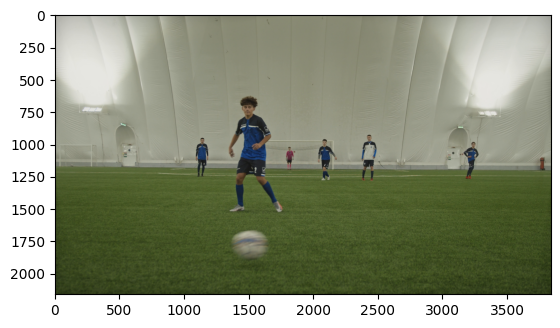

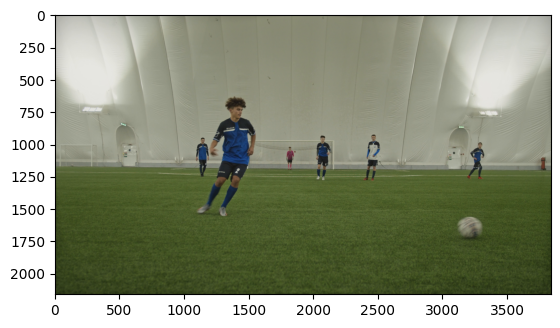

In [26]:
plt.imshow(cv2.cvtColor(saved_frame[7], cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(saved_frame[8], cv2.COLOR_BGR2RGB))
plt.show()


In [ ]:
**Day 16 title:**
`Day16_Trajectory_Visualization_YAxis_Inversion_and_Frame_to_Frame_Speed_Calculation`

**Conclusion (points):**

- Plotted smoothed trajectory (`df_smooth`) using `plt.plot()`, confirmed and
    understood *why* `invert_yaxis()` is needed — image coordinates have y=0
        at the top (bigger y = lower on screen), opposite of standard math graphs, so inversion makes the chart match real video orientation
- Used `.diff()` on `x` and `y` columns to get frame-to-frame displacement (dx, dy) without a manual loop
- Calculated Euclidean distance per frame gap: `sqrt(dx² + dy²)`
- Converted to speed using real FPS — checked via `cap.get(cv2.CAP_PROP_FPS)`
    instead of assuming 30 (actual was 25 FPS, giving 0.04s per frame)
- Found an unusually large speed spike at row 10; investigated by visually
    inspecting the underlying frames (7 and 8) rather than assuming a bug
- Confirmed via visual inspection that both detections were correct — the spike
    reflected a real, fast kick with visible motion blur, not a detection error
- Key limitation identified: speed is currently in pixels/second, a
    unitless/camera-dependent measure — not directly meaningful (e.g., can't say
    if it's a "hard kick" or "impossible") until calibrated to real-world units
    (meters), which requires a known reference distance in frame — flagged as a
      separate future topic, not done today